In [1]:
#import libraries
import numpy as np
import statistics
import math
import matplotlib.pyplot as plt
from scipy.linalg import solve
from abc import ABC, abstractmethod
#passenger counts for 10 days and fares
ntinda = np.array([35, 40, 42, 50, 55, 60, 48, 52, 47, 45])
entebbe = np.array([60, 58, 65, 70, 72, 80, 75, 68, 66, 64])
mukono = np.array([45, 47, 50, 49, 55, 62, 58, 53, 51, 50]) 

ntinda_fare = 2000
entebbe_fare = 5000
mukono_fare = 3000

In [2]:
#route class
class Route:
    def __init__(self, name, passengers, fare):
        self.name = name
        self.passengers = np.array(passengers)
        self.fare = fare
    
    def daily_revenue(self):
        return self.passengers * self.fare
    
    def total_revenue(self):
        return np.sum(self.daily_revenue())
    
    def descriptive_statistics(self):
        data = self.passengers.tolist()
        return {"mean": statistics.mean(data),"variance": statistics.variance(data),"standard_deviation": statistics.stdev(data)}
# routes
routes = {"Ntinda": Route("Kampala-Ntinda", ntinda, ntinda_fare),
    "Entebbe": Route("Kampala-Entebbe", entebbe, entebbe_fare),
    "Mukono": Route("Kampala-Mukono", mukono, mukono_fare)
}
#testing the class
for name, route in routes.items():
    print(f"\n{name}")
    print("Daily revenue:", route.daily_revenue())
    print("Total revenue:", route.total_revenue())
    print("Statistics:", route.descriptive_statistics())


Ntinda
Daily revenue: [ 70000  80000  84000 100000 110000 120000  96000 104000  94000  90000]
Total revenue: 948000
Statistics: {'mean': 47.4, 'variance': 54.266666666666666, 'standard_deviation': 7.366591251499344}

Entebbe
Daily revenue: [300000 290000 325000 350000 360000 400000 375000 340000 330000 320000]
Total revenue: 3390000
Statistics: {'mean': 67.8, 'variance': 45.06666666666667, 'standard_deviation': 6.713171133426189}

Mukono
Daily revenue: [135000 141000 150000 147000 165000 186000 174000 159000 153000 150000]
Total revenue: 1560000
Statistics: {'mean': 52, 'variance': 26.444444444444443, 'standard_deviation': 5.142416206847171}


In [3]:
#supply demand equilibrium for ntinda 120−0.02P=10+0.03P
A = np.array([[0.02, 1],[-0.03, 1]])
b = np.array([120, 10])
solution = solve(A, b)

equilibrium_price = solution[0]
equilibrium_quantity = solution[1]

print("Equilibrium fare:", equilibrium_price)
print("Equilibrium quantity:", equilibrium_quantity)


Equilibrium fare: 2200.0
Equilibrium quantity: 76.0


In [4]:
#forecasting classes
class Forecaster(ABC):
    @abstractmethod
    def forecast(self, data):
        pass
#3 day moving average
class MovingAverageForecaster(Forecaster):
    def __init__(self, window=3):
        self.window = window
    
    def forecast(self, data):
        data = np.array(data)
        if len(data) < self.window:
            raise ValueError("Not enough data for moving average.")
        return np.mean(data[-self.window:])
#exponential smoothing with tunable alpha
class ExponentialSmoothingForecaster(Forecaster):
    def __init__(self, alpha):
        self.alpha = alpha
    
    def forecast(self, data):
        data = np.array(data, dtype=float)
        smoothed = data[0]
        for value in data[1:]:
            smoothed = (self.alpha * value+ (1 - self.alpha) * smoothed)
            return smoothed
#linear trend
class LinearTrendForecaster(Forecaster):
    def forecast(self, data):
        data = np.array(data, dtype=float)
        x = np.arange(1, len(data) + 1)
        slope, intercept = np.polyfit(x, data, 1)
        next_day = len(data) + 1
        return slope * next_day + intercept

In [5]:
# rolling-origin (walk-forward) backtesting 
def moving_average_forecast(data, window=3):
    return np.mean(data[-window:])

def exponential_smoothing_forecast(data, alpha):
    smoothed = data[0]
    for value in data[1:]:
        smoothed = alpha * value + (1 - alpha) * smoothed
    return smoothed

def linear_trend_forecast(data):
    x = np.arange(1, len(data) + 1)
    slope, intercept = np.polyfit(x, data, 1)
    next_day = len(data) + 1
    return slope * next_day + intercept
def backtest_model(data, model_function, **kwargs):
    errors = []
    # Days 4 to 10
    for day in range(4, 11):
        # Use data available before the day being predicted
        training_data = data[:day-1]
        forecast = model_function(training_data, **kwargs)
        actual = data[day-1]
        error = abs(actual - forecast)
        errors.append(error)
    return np.mean(errors)

In [6]:
#MAE for moving average and linear trend
for name, route in routes.items():
    data = route.passengers
    ma_mae = backtest_model(data,moving_average_forecast,window=3)
    trend_mae = backtest_model(data,linear_trend_forecast)

    print(f"\n{name}")
    print("Moving Average MAE:", ma_mae)
    print("Linear Trend MAE:", trend_mae)


Ntinda
Moving Average MAE: 7.523809523809525
Linear Trend MAE: 7.873469387755104

Entebbe
Moving Average MAE: 7.190476190476192
Linear Trend MAE: 7.71133786848073

Mukono
Moving Average MAE: 5.333333333333333
Linear Trend MAE: 6.390589569160993


In [7]:
#tune alpha with grid search
def tune_alpha(data):
    alpha_values = np.arange(0.01, 1.00, 0.01)
    best_alpha = None
    best_mae = float("inf")
    for alpha in alpha_values:
        mae = backtest_model(data,exponential_smoothing_forecast,alpha=alpha)
        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
    return best_alpha, best_mae
for name, route in routes.items():
    alpha, mae = tune_alpha(route.passengers)
    print(f"{name}:")
    print("Best alpha:", alpha)
    print("SES MAE:", mae)

Ntinda:
Best alpha: 0.98
SES MAE: 5.8556125869244156
Entebbe:
Best alpha: 0.99
SES MAE: 4.457313536969991
Mukono:
Best alpha: 0.99
SES MAE: 3.7227995527137074


In [8]:
#compare models
results = []
for name, route in routes.items():
    data = route.passengers
    # Moving average
    ma_mae = backtest_model(data,moving_average_forecast,window=3)
    # Linear trend
    trend_mae = backtest_model(data,linear_trend_forecast)
    # Tuned exponential smoothing
    best_alpha, ses_mae = tune_alpha(data)
    results.append([name,ma_mae,ses_mae,trend_mae,best_alpha])

print("\nMAE RESULTS")
print("Route | Moving Average | SES | Linear Trend | Best Alpha")

for row in results:
    print(f"{row[0]} | "f"{row[1]:.2f} | "f"{row[2]:.2f} | "f"{row[3]:.2f} | "f"{row[4]:.2f}")


MAE RESULTS
Route | Moving Average | SES | Linear Trend | Best Alpha
Ntinda | 7.52 | 5.86 | 7.87 | 0.98
Entebbe | 7.19 | 4.46 | 7.71 | 0.99
Mukono | 5.33 | 3.72 | 6.39 | 0.99


In [9]:
#forecast day 11
day11_forecasts = {}
for name, route in routes.items():
    data = route.passengers
    best_alpha, _ = tune_alpha(data)
    forecast = exponential_smoothing_forecast(data,best_alpha)

    day11_forecasts[name] = forecast
    print(f"{name}: "f"Day 11 passengers = {forecast:.2f}, "f"alpha = {best_alpha:.2f}")

Ntinda: Day 11 passengers = 45.04, alpha = 0.98
Entebbe: Day 11 passengers = 64.02, alpha = 0.99
Mukono: Day 11 passengers = 50.01, alpha = 0.99


In [10]:
#passenger forecasts to revenue forecasts
day11_revenue = {}
for name, route in routes.items():
    passengers = day11_forecasts[name]
    revenue = passengers * route.fare
    day11_revenue[name] = revenue
    print(f"{name}: " f"UGX {revenue:,.2f}")

Ntinda: UGX 90,083.94
Entebbe: UGX 320,101.04
Mukono: UGX 150,030.62


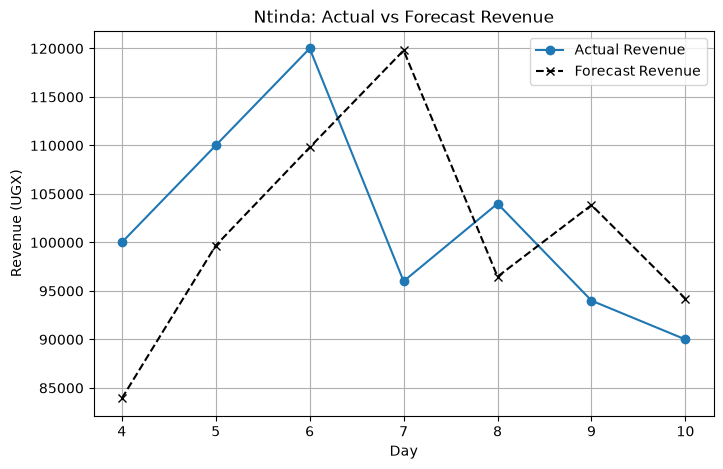

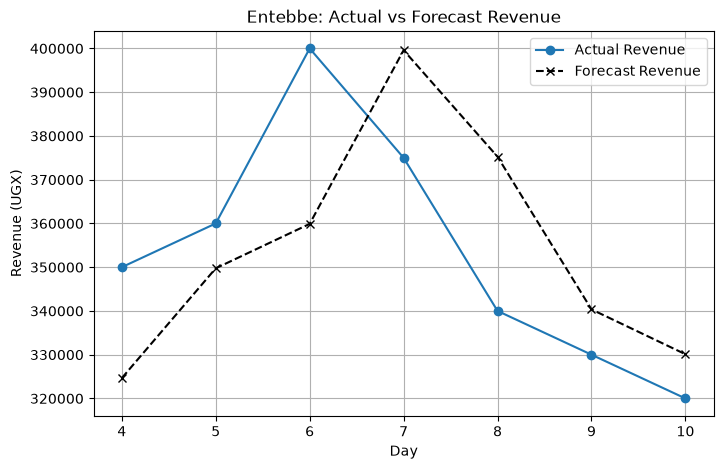

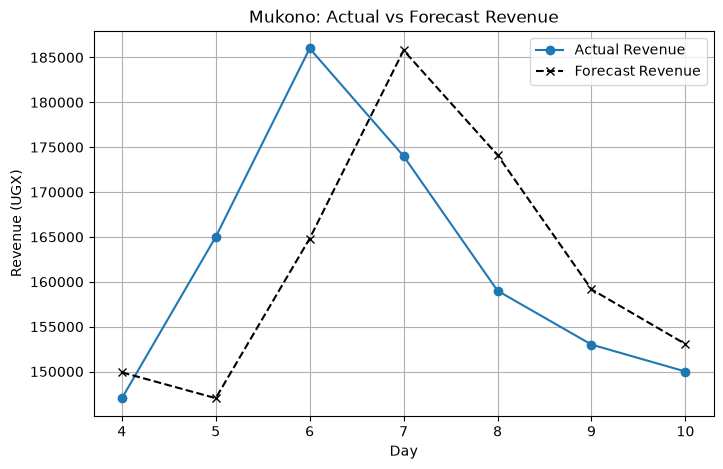

In [11]:
#actual vs forecast plot
for name, route in routes.items():
    data = route.passengers
    fare = route.fare
    best_alpha, _ = tune_alpha(data)
    forecasts = []
    # Forecast days 4-10
    for day in range(4, 11):
        training_data = data[:day-1]
        forecast = exponential_smoothing_forecast(training_data,best_alpha)
        forecasts.append(forecast * fare)

    actual_revenue = data[3:10] * fare
    days = np.arange(4, 11)
    plt.figure(figsize=(8, 5))
    plt.plot(days,actual_revenue,marker="o",label="Actual Revenue")

    plt.plot(days,forecasts,marker="x",linestyle="--",label="Forecast Revenue", color="black" )

    plt.xlabel("Day")
    plt.ylabel("Revenue (UGX)")
    plt.title(f"{name}: Actual vs Forecast Revenue")
    plt.legend()
    plt.grid(True)

    plt.show()

In [12]:
#fleet planning
fleet_plan = {}

capacity_per_vehicle = 8 * 14
buffer = 1.15

for name, route in routes.items():
    forecast_demand = day11_forecasts[name]
    buffered_demand = forecast_demand * buffer
    vehicles = math.ceil(buffered_demand / capacity_per_vehicle)

    fleet_plan[name] = vehicles
    print(f"\n{name}")
    print("Forecast demand:", round(forecast_demand, 2))
    print("Demand + 15% buffer:", round(buffered_demand, 2))
    print("Capacity per vehicle:", capacity_per_vehicle)
    print("Vehicles required:", vehicles)


Ntinda
Forecast demand: 45.04
Demand + 15% buffer: 51.8
Capacity per vehicle: 112
Vehicles required: 1

Entebbe
Forecast demand: 64.02
Demand + 15% buffer: 73.62
Capacity per vehicle: 112
Vehicles required: 1

Mukono
Forecast demand: 50.01
Demand + 15% buffer: 57.51
Capacity per vehicle: 112
Vehicles required: 1
